# House Price Prediction

This notebook performs linear regression to predict house prices based on various features.

**Steps covered:**
1. Data Exploration & Cleaning
2. Feature Selection
3. Model Training (Linear Regression)
4. Model Evaluation
5. Visualization

## 1. Data Exploration & Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('Housing.csv')
print('Shape:', df.shape)
df.head()

Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [6]:
print('Duplicates:', df.duplicated().sum())
print('\nUnique values in categorical columns:')
for col in df.select_dtypes(include='object').columns:
    print(f'{col}: {df[col].unique()}')

Duplicates: 0

Unique values in categorical columns:
mainroad: ['yes' 'no']
guestroom: ['no' 'yes']
basement: ['no' 'yes']
hotwaterheating: ['no' 'yes']
airconditioning: ['yes' 'no']
prefarea: ['yes' 'no']
furnishingstatus: ['furnished' 'semi-furnished' 'unfurnished']


## 2. Feature Selection

In [7]:
label_map = {'yes': 1, 'no': 0}
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map(label_map)

In [8]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=False).astype(int)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0


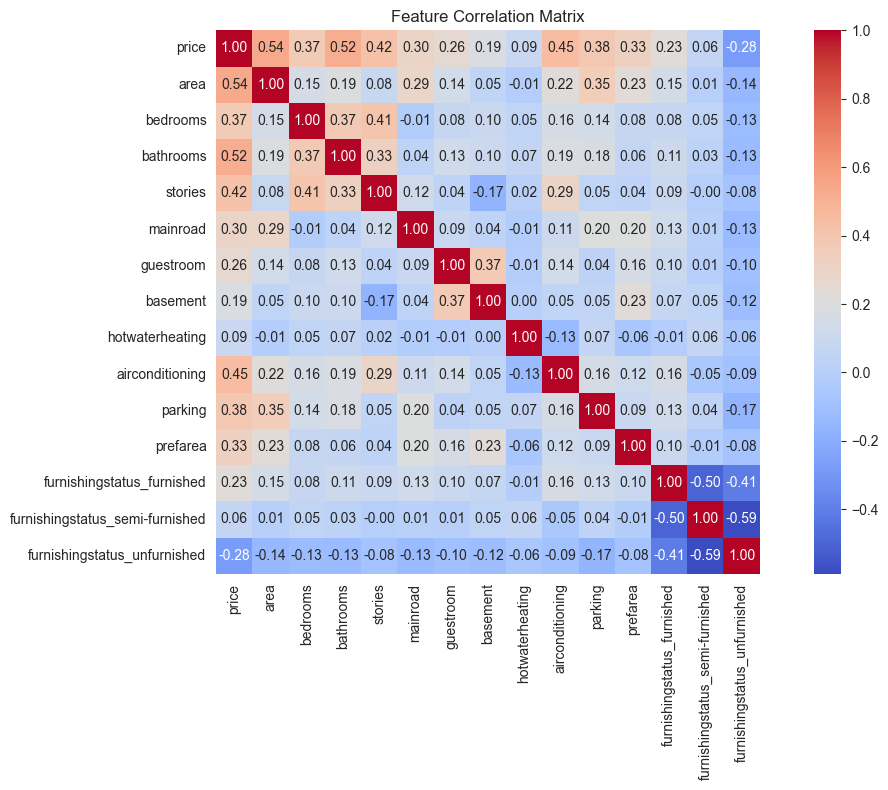

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

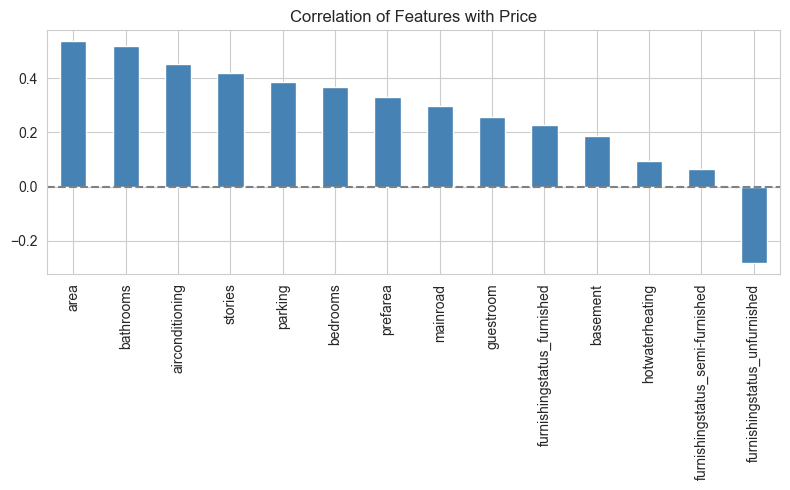

In [10]:
corr = df.corr()['price'].sort_values(ascending=False)
plt.figure(figsize=(8, 5))
corr.drop('price').plot(kind='bar', color='steelblue')
plt.title('Correlation of Features with Price')
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

## 3. Model Training (Linear Regression)

In [11]:
X = df.drop('price', axis=1)
y = df['price']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')

Training samples: 436
Test samples: 109


In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)
print('Model Coefficients:')
coef_df

Model Coefficients:


,Feature,Coefficient
2,bathrooms,549420.501241
0,area,511615.563777
8,airconditioning,367817.894916
3,stories,353158.429856
10,prefarea,267018.660812
9,parking,193542.781675
6,basement,186194.150506
7,hotwaterheating,143233.206250
4,mainroad,128151.921295
13,furnishingstatus_unfurnished,-106620.372430


## 4. Model Evaluation

In [13]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f'Training MSE: {train_mse:.2f}')
print(f'Test MSE:     {test_mse:.2f}')
print(f'Training R²:  {train_r2:.4f}')
print(f'Test R²:      {test_r2:.4f}')
print(f'\nIntercept: {model.intercept_:.2f}')

Training MSE: 968358188440.72
Test MSE:     1754318687330.67
Training R²:  0.6859
Test R²:      0.6529

Intercept: 4737518.18


## 5. Visualization

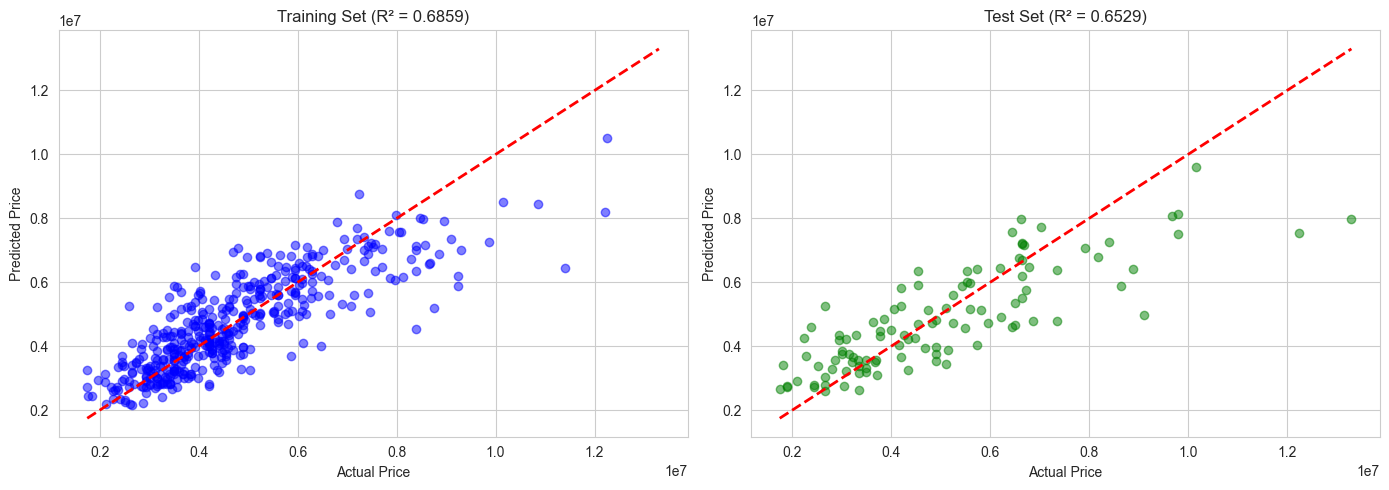

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_train, y_train_pred, alpha=0.5, color='blue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Training Set (R² = {train_r2:.4f})')

axes[1].scatter(y_test, y_test_pred, alpha=0.5, color='green')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title(f'Test Set (R² = {test_r2:.4f})')

plt.tight_layout()
plt.show()

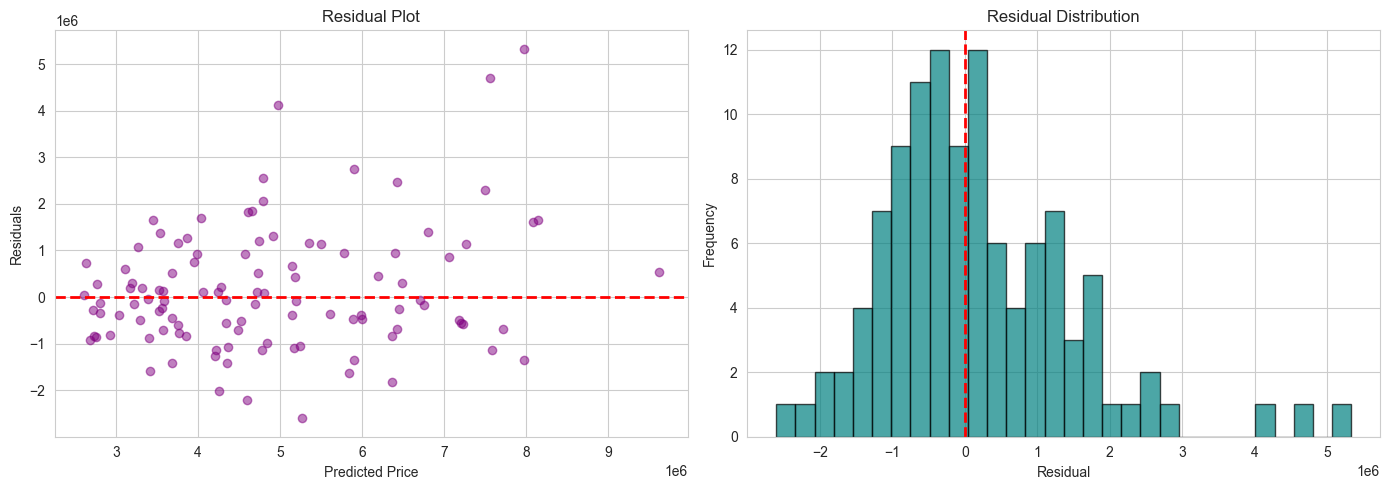

In [15]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_pred, residuals, alpha=0.5, color='purple')
axes[0].axhline(0, color='red', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot')

axes[1].hist(residuals, bins=30, edgecolor='black', color='teal', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

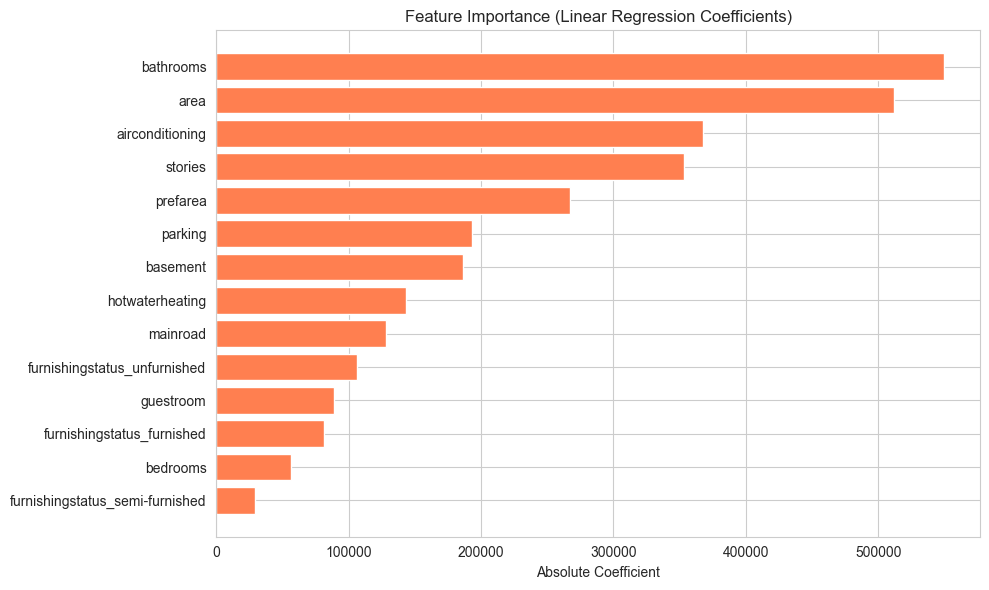

In [16]:
feature_importance = pd.DataFrame({'Feature': X.columns, 'Absolute Coefficient': np.abs(model.coef_)})
feature_importance = feature_importance.sort_values('Absolute Coefficient', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Absolute Coefficient'], color='coral')
plt.xlabel('Absolute Coefficient')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.tight_layout()
plt.show()

## Conclusion

The linear regression model was trained on housing data with features like area, bedrooms, bathrooms, etc.
- Test R² of **0.6529** indicates the proportion of variance explained by the model.
- The residual plot checks for homoscedasticity and linearity assumptions.
- Feature coefficients show which factors most influence house prices.